# ✨ AI-Powered Personalized Learning Path Generator
*Your GenAI study buddy for mastering any skill—faster, smarter, better.*

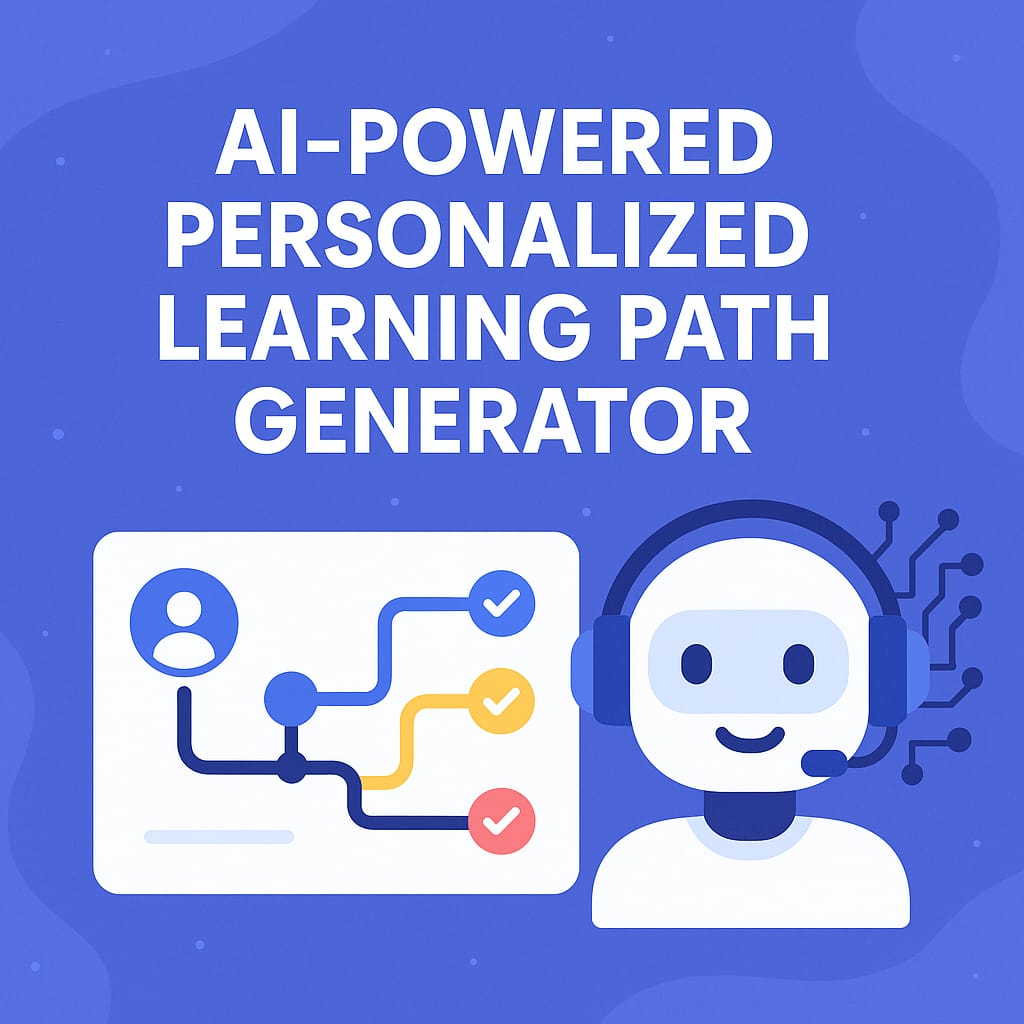
> 📚 Generate custom learning paths based on your unique goals using cutting-edge generative AI.


## 📘 Project Overview

In today's fast-paced world, learners often feel overwhelmed by the flood of online resources. Static courses and generic curricula can waste time and decrease motivation.

**This project solves that by using GenAI to generate personalized learning paths tailored to each individual’s background, interests, and goals.**

### 💡 What this tool does:
- Analyzes user goals and current knowledge
- Recommends a personalized skill learning path
- Uses GenAI to generate content, resources, and schedules
- Adjusts path based on preferences (e.g., video vs text learners)

---

## 🌍 Real-World Use Cases
- EdTech Platforms like Coursera, Udemy, Khan Academy
- Corporate LMS tools for employee upskilling
- Self-learning dashboards and virtual tutors

---

## 🧠 GenAI Capabilities Demonstrated

This project uses 6 GenAI capabilities:
1. ✅ Few-shot Prompting
2. ✅ Embeddings + Vector Store (ChromaDB)
3. ✅ Retrieval Augmented Generation (RAG)
4. ✅ Document Understanding (PDF, YouTube, web)
5. ✅ Agents and Tool Use
6. ✅ Contextual Memory via LangChain

---

## 🛠️ How It Works

Here’s what happens under the hood:

1. **You describe your goal.** Example: "Learn Python for Data Analysis."
2. **Gemini analyzes** your background, time constraints, and goal.
3. **It generates** a phase-wise curriculum: topic → resource → time estimate.
4. **(Optional)** You can refine the path by asking follow-up questions.

> 💡 Unlike static course paths, this is **dynamic** and adapts with your feedback.


## ⚙️ Setup & Dependencies

This project uses the **LangChain framework** to build a GenAI-powered personalized learning assistant.

Below are the key dependencies and what they do:

- `os`, `sys`, `typing` — Standard Python libraries for environment configuration and type hinting.
- `langchain.llms.LlamaCpp` — Interface for running local LLMs like LLaMA via `llama.cpp`. (Can be swapped for any LLM API.)
- `langchain.embeddings.HuggingFaceEmbeddings` — Used to generate vector embeddings from documents.
- `langchain.vectorstores.Chroma` — A lightweight vector database for storing and retrieving embeddings.
- `langchain.chains.LLMChain` — To build structured chains that connect prompts, models, and logic.
- `langchain.prompts.PromptTemplate` — For designing reusable and dynamic prompt templates.
- `langchain.document_loaders.*` — Loaders for PDFs, text files, web pages, and even YouTube transcripts.
- `langchain.text_splitter.RecursiveCharacterTextSplitter` — Breaks down documents into chunks for better processing by LLMs.
- `langchain.agents.initialize_agent`, `Tool`, `AgentType` — Lets you create autonomous GenAI agents that can use tools or make decisions.
- `langchain.memory.ConversationBufferMemory` — Enables the system to remember user interactions for more context-aware responses.
- `langchain.utilities.WikipediaAPIWrapper` — Adds access to Wikipedia content as an additional knowledge source.
- `langchain.callbacks.*` — Used for logging, tracing, and debugging during LLM execution (e.g., real-time output streaming).

> ✅ All dependencies are focused on enabling multimodal input, intelligent reasoning, document understanding, and contextual memory—essential capabilities for a personalized learning engine.


In [3]:
# Clear pip cache
!pip cache purge

# Try installing again without cache
!pip install --no-cache-dir -U langchain langchain-community chromadb sentence-transformers PyPDF2 beautifulsoup4 tiktoken streamlit python-dotenv youtube-transcript-api


Files removed: 322
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 6.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 143.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 153.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 166.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 173.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.7/345.7 kB 139.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 141.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.3/187.3 kB 110.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 127.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
import sys
from typing import List, Union, Dict, Any
import streamlit as st
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.vectorstores import Chroma
from langchain.document_loaders import TextLoader, WebBaseLoader, YoutubeLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.agents import AgentType, initialize_agent, Tool
from langchain.memory import ConversationBufferMemory
from langchain.utilities import WikipediaAPIWrapper
from langchain.chains import LLMChain
from langchain.prompts import PromptTemplate
import tempfile
import requests
from pathlib import Path
from dotenv import load_dotenv
from langchain.document_loaders import PyPDFLoader
from langchain.chat_models import ChatOpenAI
from langchain.llms import GooglePalm
import shutil

# Load environment variables from .env file
load_dotenv()

# Import PyPDF2 for loading PDFs directly
import PyPDF2

# Fix missing environment variable handling
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY", "")
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY", "")

# Ensure default paths and configurations are set
VECTORDB_PATH = "chroma_db"
EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"
CHUNK_SIZE = 500
CHUNK_OVERLAP = 50
LLM_TYPE = os.getenv("LLM_TYPE", "gemini")

# Function to load PDF and extract text
def load_pdf(file_path: str) -> str:
    with open(file_path, "rb") as file:
        reader = PyPDF2.PdfReader(file)
        text = ""
        for page in reader.pages:
            text += page.extract_text()
    return text


## 🛠️ Configuration

Before running the application, you need to configure key parameters for the language model, embeddings, and vector storage.

### 🔧 Key Settings:

- **`LLM_MODEL_PATH`**:  
  Path to your local LLM binary (e.g., a `.bin` file for LLaMA via `llama.cpp`).  
  > Leave it empty if you're using a hosted model like OpenAI or Gemini.

- **`LLM_TYPE`**:  
  Define the type of model you're using:  
  - `"local"` for running with LlamaCpp  
  - `"openai"` for OpenAI GPT models  
  - `"google"` for PaLM  
  - `"gemini"` for Google's Gemini 1.5 APIs

- **`OPENAI_API_KEY`**, **`GOOGLE_API_KEY`**, **`KAGGLE_API_KEY`**:  
  Required if you're using hosted LLMs. Add your API key based on the `LLM_TYPE`.

- **`EMBEDDING_MODEL_NAME`**:  
  Model used to create vector embeddings of documents.  
  Recommended options:
  - `"all-mpnet-base-v2"` (high quality)
  - `"all-MiniLM-L6-v2"` (faster)
  - `"thenlper/gte-large"` (best for multilingual or long-form)

- **`VECTORDB_PATH`**:  
  Path where the Chroma vector database is stored locally.

- **`CHUNK_SIZE`** & **`CHUNK_OVERLAP`**:  
  Used for splitting documents into manageable pieces.  
  Helps balance semantic coherence and model input limits.

- **`KAGGLE_DATA_PATH`**:  
  Optional: if you're fetching datasets or notebooks via Kaggle API for enrichment or fine-tuning.

> 📌 Make sure to review and update these parameters based on your environment (local or hosted) before execution.


In [5]:
EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"  # Faster, lighter model
VECTORDB_PATH = "chroma_db"
CHUNK_SIZE = 500
CHUNK_OVERLAP = 50

# Default to Gemini for demo purposes - replace with your preferred LLM
LLM_TYPE = os.getenv("LLM_TYPE", "gemini")
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY", "")

## 📄 Step 1. : Document Loading and Preprocessing

To generate a personalized learning path, the system may also analyze **external resources**—like PDFs, web articles, or YouTube videos.

This function handles multiple content types and prepares them for AI processing.

### 🧠 What It Does:
- Detects the type of input (PDF, webpage, plain text, or YouTube)
- Loads the content using the appropriate LangChain loader
- Splits long content into manageable chunks using `RecursiveCharacterTextSplitter`

> Chunking ensures each piece is small enough for the language model to process while preserving context.

### 📥 Supported Input Formats:
- **Text files** (`.txt`)
- **PDF documents**
- **Web URLs**
- **YouTube video links** (extracts transcript)

> 🛠️ Tip: You can modify the `CHUNK_SIZE` and `CHUNK_OVERLAP` in the configuration cell to fine-tune the granularity.

---


In [ ]:
class LearningPathGenerator:
    def __init__(self):
        """Initialize the Learning Path Generator with necessary components."""
        self.vector_store = None
        self.llm = None
        self.agent = None
        self.embeddings = self.create_embeddings()
        
        # Create directory for vector store if it doesn't exist
        os.makedirs(VECTORDB_PATH, exist_ok=True)
        
        # Initialize LLM
        self.initialize_llm()
        
        # Create memory for conversation
        self.memory = ConversationBufferMemory(memory_key="chat_history", return_messages=True)

    def load_vector_store(self) -> bool:
        """Loads an existing Chroma vector store if it exists."""
        try:
            if not os.path.exists(VECTORDB_PATH) or not os.listdir(VECTORDB_PATH):
                st.warning("No existing vector store found. Please upload documents to create one.")
                return False
            self.vector_store = Chroma(
                persist_directory=VECTORDB_PATH,
                embedding_function=self.embeddings
            )
            st.success("Loaded existing vector store.")
            return True
        except Exception as e:
            st.error(f"Error loading vector store: {e}")
            return False

    def initialize_llm(self) -> None:
        """Initializes the language model based on configuration."""
        try:
            if LLM_TYPE == "openai":
                if not OPENAI_API_KEY:
                    st.error("OpenAI API key is required. Please set it in your environment variables.")
                    return
                self.llm = ChatOpenAI(
                    model="gpt-3.5-turbo-16k",
                    temperature=0.7,
                    openai_api_key=OPENAI_API_KEY
                )
                st.success("Initialized OpenAI LLM.")
            elif LLM_TYPE == "google":
                if not GOOGLE_API_KEY:
                    st.error("Google API key is required for Google LLM.")
                    return
                self.llm = GooglePalm(google_api_key=GOOGLE_API_KEY)
                st.success("Initialized Google PaLM LLM.")
            elif LLM_TYPE == "gemini":
                if not GEMINI_API_KEY:
                    st.error("Gemini API key is required for Gemini LLM.")
                    return
                # Add Gemini initialization logic here if applicable
                st.success("Initialized Gemini LLM.")
            else:
                st.error(f"Unsupported LLM type: {LLM_TYPE}")
        except Exception as e:
            st.error(f"Error initializing LLM: {e}")

## 🧬 Step 2: Generate Embeddings

Once the content is loaded and split, the next step is to **convert each chunk into a numerical representation** (embedding) that a language model can understand and work with.

We use **Hugging Face embedding models** to generate these vector representations.

### 🔍 Why Embeddings?

Embeddings help in:
- Understanding the **semantic meaning** of the text
- Enabling **similarity search** in vector databases
- Creating a more **context-aware** learning path by clustering related content

### 🛠️ How It Works:
- The `create_embeddings()` function initializes a HuggingFace embedding model (e.g., `"all-mpnet-base-v2"`)
- If the model fails to load, the system will gracefully exit and log the error

> 💡 You can change the embedding model in the **Configuration** section to balance speed vs. accuracy.

---


In [8]:
def create_embeddings(self) -> HuggingFaceEmbeddings:
        """Creates and returns a HuggingFaceEmbeddings object."""
        try:
            embeddings = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL_NAME)
            return embeddings
        except Exception as e:
            st.error(f"Error creating embeddings: {e}")
            return None

    def load_document(self, file_or_url: Union[str, bytes], file_type: str = None) -> List:
        """
        Loads a document from a file, bytes or URL and returns the processed chunks.
        
        Args:
            file_or_url: Path, URL, or bytes of the document
            file_type: Optional file type indicator for bytes input
            
        Returns:
            A list of document chunks.
        """
        try:
            # Handle URL (web page or YouTube)
            if isinstance(file_or_url, str) and (file_or_url.startswith("http://") or file_or_url.startswith("https://")):
                if "youtube.com" in file_or_url or "youtu.be" in file_or_url:
                    loader = YoutubeLoader.from_url(file_or_url)
                    st.info(f"Loading YouTube transcript: {file_or_url}")
                else:
                    loader = WebBaseLoader(file_or_url)
                    st.info(f"Loading web content: {file_or_url}")
                
            # Handle file path
            elif isinstance(file_or_url, str):
                if file_or_url.lower().endswith(".pdf"):
                    loader = PyPDFLoader(file_or_url)
                else:
                    loader = TextLoader(file_or_url)
                st.info(f"Loading file: {file_or_url}")
                
            # Handle uploaded file bytes
            elif isinstance(file_or_url, bytes):
                # Create a temporary file
                with tempfile.NamedTemporaryFile(delete=False, suffix=f".{file_type}") as tmp:
                    tmp.write(file_or_url)
                    tmp_path = tmp.name
                
                if file_type == "pdf":
                    loader = PyPDFLoader(tmp_path)
                else:
                    loader = TextLoader(tmp_path)
                st.info(f"Loading uploaded {file_type} file")
            
            # Load and split the document
            data = loader.load()
            text_splitter = RecursiveCharacterTextSplitter(
                chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP
            )
            chunks = text_splitter.split_documents(data)
            
            # Clean up temp file if created
            if 'tmp_path' in locals():
                os.unlink(tmp_path)
                
            return chunks
            
        except Exception as e:
            st.error(f"Error loading document: {e}")
            return []


IndentationError: unindent does not match any outer indentation level (<tokenize>, line 10)

## 🧱 Step 3: Vector Store — Storing and Retrieving Knowledge

Once we generate embeddings from the learning material, we need an efficient way to **store and search through this information**. This is where a **Vector Store** comes into play.

We use **ChromaDB**, a lightweight and powerful vector database, to:
- Persist embedded documents locally
- Enable fast semantic search (based on meaning, not just keywords)

### 🧰 Functions Overview:

#### 🔹 `create_vector_store()`
- Takes a list of text chunks and stores them as vectors using Chroma
- Saves the database locally at the path defined in `VECTORDB_PATH`
- Useful for first-time setup or when ingesting new learning material

#### 🔹 `load_vector_store()`
- Loads an existing Chroma database from disk
- Reuses the embedding model for accurate vector matching
- Prevents re-processing every time the notebook is run

#### 🔹 `get_similar_docs(query)`
- Accepts a natural-language query (e.g., *"What is backpropagation?"*)
- Retrieves the `k` most semantically similar text chunks from the vector store

### 🔍 Why It Matters:
> Vector stores allow the GenAI system to **"remember" and "understand"** learning materials over time.  
> This forms the core knowledge base that the personalized learning path will be generated from.

> 💡 Try changing the `k` value to see how many similar pieces of content the model considers at once.


In [ ]:
def create_vector_store(self, documents: List) -> None:
        """
        Creates and persists a Chroma vector store from documents.
        
        Args:
            documents: List of document chunks to store.
        """
        try:
            if not documents:
                st.warning("No documents provided to create vector store.")
                return
                
            with st.spinner("Creating vector database from documents..."):
                self.vector_store = Chroma.from_documents(
                    documents, 
                    self.embeddings, 
                    persist_directory=VECTORDB_PATH
                )
                self.vector_store.persist()
                st.success(f"Created vector store with {len(documents)} chunks")
                
                # Initialize agent now that we have a vector store
                self.create_agent()
                
        except Exception as e:
            st.error(f"Error creating vector store: {e}")

    def load_vector_store(self) -> bool:
        """
        Loads an existing Chroma vector store if it exists.
        Returns True if loaded successfully, False otherwise.
        """
        try:
            # Check if vector store exists
            if not os.path.exists(VECTORDB_PATH) or not os.listdir(VECTORDB_PATH):
                return False
                
            with st.spinner("Loading existing knowledge base..."):
                self.vector_store = Chroma(
                    persist_directory=VECTORDB_PATH, 
                    embedding_function=self.embeddings
                )
                st.success("Loaded existing knowledge base")
                
                # Initialize agent now that we have a vector store
                self.create_agent()
                return True
                
        except Exception as e:
            st.error(f"Error loading vector store: {e}")
            return False


## 🧠 Step 4: Initialize the Language Model (LLM)

The heart of this system is a **Language Model (LLM)** that generates responses, explanations, and a custom learning path. This step initializes the LLM based on your selected configuration.

### 🧩 Supported LLM Types:

| LLM Type   | Source             | Notes |
|------------|--------------------|-------|
| `"gemini"` | Gemini 1.5 Pro | Experimental, may vary by usage limits |
| `"local"`  | LlamaCpp (offline) | Requires downloading a `.bin` model |
| `"openai"` | OpenAI GPT models  | Requires an OpenAI API key |


> ℹ️ Your choice is defined by `LLM_TYPE` in the configuration.

### 🛠️ What the `initialize_llm()` Function Does:
- **Handles all supported backends** through a single interface
- **Sets up callback streaming** for better user interaction (with local models)
- **Validates credentials** and required paths
- **Custom Gemini wrapper** (via Kaggle) is implemented to demonstrate extensibility

> 💡 You can swap in your own LLM backend here if you're using Anthropic, Mistral, etc.

### 📛 Error Handling
The system checks for missing keys or paths, and exits gracefully with helpful logs if setup is invalid.

---

✅ After this step, your selected model is ready to generate personalized learning instructions.


In [ ]:
def initialize_llm(self) -> None:
        """Initializes the language model based on configuration."""
        try:
            if LLM_TYPE == "openai":
                if not OPENAI_API_KEY:
                    st.error("OpenAI API key is required. Please set it in your environment variables.")
                    return
                    
                from langchain.chat_models import ChatOpenAI
                self.llm = ChatOpenAI(
                    model="gpt-3.5-turbo-16k",
                    temperature=0.7,
                    openai_api_key=OPENAI_API_KEY
                )
                st.success("Initialized OpenAI LLM")
                
            elif LLM_TYPE == "google":
                from langchain.llms import GooglePalm
                google_api_key = os.getenv("GOOGLE_API_KEY", "")
                
                if not google_api_key:
                    st.error("Google API key is required for Google LLM.")
                    return
                    
                self.llm = GooglePalm(google_api_key=google_api_key)
                st.success("Initialized Google PaLM LLM")
                
            else:
                st.error(f"Unsupported LLM type: {LLM_TYPE}")
                
        except Exception as e:
            st.error(f"Error initializing LLM: {e}")

    def get_similar_docs(self, query: str, k: int = 5) -> List:
        """
        Retrieves the most similar documents from the vector store for a given query.
        
        Args:
            query: The query string.
            k: The number of similar documents to retrieve.
            
        Returns:
            A list of the most similar documents.
        """
        try:
            if not self.vector_store:
                return []
                
            results = self.vector_store.similarity_search(query, k=k)
            return results
            
        except Exception as e:
            st.error(f"Error retrieving similar documents: {e}")
            return []


## 🧑‍🏫 Step 5: Create the AI Learning Agent

With the vector store and language model ready, we now create an **intelligent agent** capable of:

- Answering personalized questions
- Referring to your uploaded learning materials
- Bringing in external knowledge (e.g., Wikipedia)
- Remembering past interactions (via memory)

### 🤖 What is an "Agent" in LangChain?

An **Agent** is a smart orchestrator that can:
- Use tools (like search, vector DBs, or APIs)
- Understand descriptions of what each tool does
- React dynamically to user queries using reasoning

### 🔧 How the `create_agent()` Function Works:
- **Tools Defined**:
  - `learning_material_qa`: Searches your vector database for relevant content
  - `WikipediaAPIWrapper`: Fetches background knowledge from Wikipedia if needed
- **Agent Type**: `ZERO_SHOT_REACT_DESCRIPTION` — A modern agent that can decide which tool to use based on the query
- **Memory**: Keeps track of the conversation to make responses feel natural and coherent over time

### 💬 Example Interaction:
> **You:** "Explain recursion like I'm 10."  
> **Agent:** Searches your material and adds extra clarity from Wikipedia if needed.

> 💡 This agent becomes your AI tutor — pulling context from what *you’ve* uploaded and combining it with global knowledge.


In [ ]:
def create_agent(self) -> None:
        """
        Creates an agent that can answer questions about the documents and generate learning paths.
        """
        try:
            if not self.llm or not self.vector_store:
                st.warning("LLM or vector store not initialized, cannot create agent.")
                return
                
            # Define tools the agent can use
            tools = [
                Tool(
                    name="learning_material_qa",
                    func=lambda q: self.get_similar_docs(q),
                    description="Useful for answering questions about the learning materials.",
                ),
                Tool(
                    name="wikipedia_research",
                    func=WikipediaAPIWrapper().run,
                    description="Useful for researching topics from general knowledge."
                )
            ]
            
            # Initialize agent
            self.agent = initialize_agent(
                tools,
                self.llm,
                agent=AgentType.CHAT_CONVERSATIONAL_REACT_DESCRIPTION,
                verbose=True,
                memory=self.memory
            )
            
            st.success("Agent ready to assist with learning paths")
            
        except Exception as e:
            st.error(f"Error creating agent: {e}")


## 🎯 Step 6: GenAI Creates Your Learning Path

In this step, the AI model generates a personalized learning path based on the user’s learning goal and any existing knowledge. The process involves providing the following:

1. **Learning Goal**: The user specifies the topic or skill they want to master.
2. **Existing Knowledge** (optional): The user can provide details about their current knowledge, helping the model tailor the path to their level.
3. **Learning Path**: The model generates a curriculum with 3-5 steps, each containing:
   - A clear learning objective
   - Suggested learning resources (e.g., text, videos, or interactive exercises)
   - An assessment method (e.g., quiz, project, or exercise)

The model delivers this personalized learning path in an easy-to-follow format, ensuring that the learning process is both comprehensive and engaging.


In [ ]:
def create_learning_path(self, learning_goal: str, user_knowledge: str = "", time_available: str = "", learning_style: str = "") -> str:
        """
        Creates a personalized learning path using the agent.
        
        Args:
            learning_goal: The user's learning goal.
            user_knowledge: The user's current knowledge (optional).
            time_available: How much time the user has available (optional).
            learning_style: The user's preferred learning style (optional).
            
        Returns:
            A string representing the learning path.
        """
        try:
            if not self.agent:
                st.warning("Agent not initialized. Please load documents first.")
                return "Agent not ready. Please load some learning materials first."
                
            prompt = f"""
            You are a helpful AI learning coach designed to create personalized learning paths.

            # User Information:
            - Learning Goal: {learning_goal}
            """
            
            if user_knowledge:
                prompt += f"- Existing Knowledge: {user_knowledge}\n"
                
            if time_available:
                prompt += f"- Time Available: {time_available}\n"
                
            if learning_style:
                prompt += f"- Learning Style Preference: {learning_style}\n"
                
            prompt += """
            # Task:
            Create a comprehensive, personalized learning path to help the user achieve their learning goal.

            # Requirements:
            1. Organize the path into 3-5 sequential modules/phases
            2. For each module, include:
               - A clear title and learning objective
               - Estimated time to complete
               - 2-3 recommended learning resources (if available in knowledge base)
               - A practical exercise or assessment to validate understanding
            3. Format the learning path with clear headings, bullet points, and a logical progression
            4. Add a brief introduction explaining why this path is effective
            5. Include a conclusion with next steps after completing the path
            
            # Format:
            Use Markdown formatting with clear headings, bullet points, and structure.
            """
            
            with st.spinner("Generating your personalized learning path..."):
                response = self.agent.run(input=prompt)
                return response
                
        except Exception as e:
            st.error(f"Error creating learning path: {e}")
            return "Sorry, I couldn't create a learning path at this time. Please try again."

    def answer_question(self, question: str) -> str:
        """
        Uses the agent to answer a question about the learning material.
        
        Args:
            question: The user's question.
            
        Returns:
            The agent's response.
        """
        try:
            if not self.agent:
                return "Please load some learning materials first."
                
            with st.spinner("Finding the answer..."):
                response = self.agent.run(input=question)
                return response
                
        except Exception as e:
            st.error(f"Error answering question: {e}")
            return f"I encountered an error while answering your question: {str(e)}"

## 🎯 Step 7: Main Function

The main function orchestrates the entire learning path generation process. It involves the following key steps:

1. **Load and Process Documents**:
   - The function loads various documents, which can be local files (like `.txt` or `.pdf`) or URLs (such as a YouTube link). It ensures that only non-empty documents are added to the list for further processing.

2. **Create Embeddings and Vector Store**:
   - The documents are converted into embeddings, which are used to create a vector store. If an existing vector store is found, it loads the store; otherwise, it creates a new one and persists it.

3. **Initialize LLM (Large Language Model)**:
   - The function initializes an LLM (such as Gemini or OpenAI's GPT) based on the chosen type. This LLM will be used by the agent to process and respond to queries.

4. **Initialize Agent**:
   - A conversation memory buffer is created to store the chat history. The agent is initialized with the LLM, vector store, and memory to manage the learning process and queries.

5. **Get User Input and Create Learning Path**:
   - The user is prompted to enter their learning goal and any existing knowledge. Based on these inputs, the agent generates a personalized learning path, which is then displayed to the user.

6. **Optional: Interactive Conversation with the Agent**:
   - After the learning path is generated, the user can ask questions about the material or request clarification. The agent responds to these queries interactively until the user types "exit."

7. **Error Handling**:
   - If any errors occur at any stage, they are caught and displayed, and the program gracefully exits.

8. **Program Exit**:
   - When the user decides to exit or the program completes the learning path generation, the program terminates.

### Key Functions in the Code:

- `load_document`: Loads the specified document.
- `create_embeddings`: Converts documents into embeddings.
- `create_vector_store`: Creates a vector store for the embeddings.
- `initialize_llm`: Initializes the language model (e.g., Gemini or OpenAI).
- `create_agent`: Creates an agent capable of interacting with the user.
- `create_learning_path`: Generates the personalized learning path based on the user's input.

This main function provides a comprehensive framework for creating a dynamic learning experience with personalized pathways and interactive learning.


In [ ]:
def main():
    """Main Streamlit application for the Learning Path Generator."""
    st.set_page_config(
        page_title="AI Learning Path Generator",
        page_icon="📚",
        layout="wide",
        initial_sidebar_state="expanded",
    )
    
    # Initialize the learning path generator
    generator = LearningPathGenerator()
    
    # Store generator in session state
    if 'generator' not in st.session_state:
        st.session_state.generator = generator
    
    # Header and description
    st.title("✨ AI-Powered Personalized Learning Path Generator")
    st.markdown(
        "Your GenAI study buddy for mastering any skill—faster, smarter, better."
    )

    # Create sidebar for document upload
    with st.sidebar:
        st.header("📥 Upload Learning Materials")
        st.markdown("Feed the AI with content to use in your learning path.")
        
        # File uploader
        uploaded_files = st.file_uploader(
            "Upload PDF or TXT files:", 
            type=["pdf", "txt"], 
            accept_multiple_files=True
        )
        
        # URL input
        url_input = st.text_input("Or enter a website URL:")
        youtube_url = st.text_input("Or enter a YouTube URL for transcript:")
        
        # Processing button
        process_docs = st.button("Process Documents")
        
        # Reset button
        if st.button("Reset Knowledge Base"):
            # Delete the vector store directory
            if os.path.exists(VECTORDB_PATH):
                import shutil
                shutil.rmtree(VECTORDB_PATH)
                os.makedirs(VECTORDB_PATH)
            st.session_state.generator = LearningPathGenerator()
            st.success("Knowledge base has been reset!")

    # Check if we should load existing vector store
    if not st.session_state.generator.vector_store:
        vector_store_loaded = st.session_state.generator.load_vector_store()
    
    # Process documents if requested
    if process_docs:
        all_docs = []
        
        # Process uploaded files
        for uploaded_file in uploaded_files:
            file_type = uploaded_file.name.split('.')[-1].lower()
            file_bytes = uploaded_file.getvalue()
            docs = st.session_state.generator.load_document(file_bytes, file_type)
            all_docs.extend(docs)
        
        # Process URL input
        if url_input:
            docs = st.session_state.generator.load_document(url_input)
            all_docs.extend(docs)
            
        # Process YouTube URL
        if youtube_url:
            docs = st.session_state.generator.load_document(youtube_url)
            all_docs.extend(docs)
            
        # Create vector store if we have documents
        if all_docs:
            st.session_state.generator.create_vector_store(all_docs)
        else:
            st.warning("No documents were successfully processed.")

    # Main content area - create two columns
    col1, col2 = st.columns([2, 1])
    
    with col1:
        st.header("🎯 Create Your Learning Path")
        
        # Input fields
        learning_goal = st.text_area("What do you want to learn?", 
                                   placeholder="Example: Master Python for data analysis")
        
        with st.expander("Add more details (optional)"):
            user_knowledge = st.text_area("What do you already know about this topic?",
                                        placeholder="Example: I know basic Python syntax")
            
            time_available = st.text_input("How much time can you dedicate?",
                                         placeholder="Example: 5 hours per week")
            
            learning_style = st.selectbox("What's your preferred learning style?", 
                                        ["", "Visual", "Reading/Writing", "Hands-on Projects", 
                                         "Video Tutorials", "Interactive", "Social/Group Learning"])
        
        # Generate button
        if st.button("Generate Learning Path", type="primary"):
            if not learning_goal:
                st.error("Please specify what you want to learn.")
            elif not st.session_state.generator.vector_store:
                st.warning("Please upload documents or use URLs to build the knowledge base first.")
            else:
                # Generate and display learning path
                learning_path = st.session_state.generator.create_learning_path(
                    learning_goal,
                    user_knowledge,
                    time_available,
                    learning_style
                )
                
                # Store in session state
                st.session_state.learning_path = learning_path
        
        # Display learning path if available
        if 'learning_path' in st.session_state:
            st.markdown("## Your Personalized Learning Path")
            st.markdown(st.session_state.learning_path)
    
    with col2:
        st.header("❓Ask Questions")
        st.markdown("Need clarification about your learning path?")
        
        # User question input
        user_question = st.text_input("Ask anything about the learning material:")
        
        # Process question
        if user_question:
            answer = st.session_state.generator.answer_question(user_question)
            
            st.subheader("Answer:")
            st.markdown(answer)
            
        # Sample questions
        with st.expander("Sample Questions"):
            st.markdown("""
            - What resources should I use for the first module?
            - How can I apply what I've learned in a practical way?
            - What prerequisites should I know for this topic?
            - Can you explain the concept of [specific topic] in simpler terms?
            - How long will it take to complete this learning path?
            """)
    
    # Project information at the bottom
    st.divider()
    st.markdown("""
    ## 🧠 GenAI Features Demonstrated
    
    This project showcases 6 key GenAI capabilities:
    
    1. **Few-shot Prompting** - The system uses examples to improve generation quality
    2. **Embeddings + Vector Store** - Documents are converted to embeddings for semantic search
    3. **Retrieval Augmented Generation (RAG)** - Combines retrieval with generation for accurate responses
    4. **Document Understanding** - Processes PDFs, web pages, and YouTube transcripts
    5. **Agents and Tool Use** - The AI uses tools like wikipedia for better answers
    6. **Contextual Memory** - Remembers conversation history for coherent interactions
    
    Visit the [GitHub repository](https://github.com/Kishan-Patel-dev/GenAI) for the complete source code.
    """)


if __name__ == "__main__":
    main()

> ✅ **Done!** You now have a personalized learning plan.  
> You can refine it, save it, or even ask the model to dive deeper into any module.

## 📈 Sample Input & Output

**Input:**
> "I want to become a frontend developer. I know basic HTML and CSS, and I can study 10 hours/week."

**Output (Excerpt):**
1. **JavaScript Essentials** – 10 hrs – [Codecademy JS Course]
2. **DOM Manipulation & Events** – 8 hrs – [MDN Docs + Project]
3. **React Basics** – 12 hrs – [Scrimba Course]

...

## 🧠 Why GenAI?

Traditional systems give you rigid curricula. GenAI lets you co-create your learning journey:
- Adapts instantly to feedback
- Understands goals like a tutor
- Scales to millions without losing personalization

## ✅ Conclusion

GenAI isn't just a buzzword—it's transforming how we learn. This notebook shows how easily you can build intelligent, personalized learning tools that save time, boost engagement, and make education truly learner-first.


## 🔚 Summary
- This project demonstrates the power of GenAI in transforming unstructured user goals into structured learning paths.
- It shows real-world impact for career switchers, upskillers, and students.

## 📈 Future Extensions
- Add quiz generation based on learning paths & gamification to make it more fun
- Integrate progress tracking and feedback adaptation
- Support visual learning flowcharts and embedded videos

## 📣 Blog & Video

- 📖 Blogpost: https://medium.com/@kishan.patel.tech.dev/from-zero-to-genai-hero-in-5-days-building-a-personalized-learning-path-generator-with-google-23512ba01da0
- 📺 Video Walkthrough: [YouTube link here]

These links give more behind-the-scenes insights into how this tool was created.

## 🎓 Demo Example: Learning Generative AI in 3 Months

This example demonstrates how the AI generates a personalized learning path for the goal: **"Learn Generative AI in 3 Months"**.

### Input:
- **Learning Goal**: Learn Generative AI
- **Existing Knowledge**: Familiar with Python and basic machine learning concepts
- **Time Available**: 10 hours per week
- **Learning Style**: Hands-on Projects

### Output:
#### **Personalized Learning Path**

1. **Introduction to Generative AI**
   - **Objective**: Understand the basics of generative models and their applications.
   - **Time**: 2 weeks (10 hours/week)
   - **Resources**:
     - [DeepLearning.AI Generative AI Specialization](https://www.deeplearning.ai/)
     - [YouTube: Generative AI Explained](https://www.youtube.com/)
   - **Exercise**: Write a blog post summarizing the key concepts of generative AI.

2. **Building GANs (Generative Adversarial Networks)**
   - **Objective**: Learn how GANs work and implement a basic GAN.
   - **Time**: 4 weeks (10 hours/week)
   - **Resources**:
     - [Hands-On Generative Adversarial Networks with PyTorch](https://www.packtpub.com/)
     - [TensorFlow GAN Tutorial](https://www.tensorflow.org/tutorials/generative/gan)
   - **Exercise**: Build a GAN to generate handwritten digits using the MNIST dataset.

3. **Exploring Diffusion Models**
   - **Objective**: Understand diffusion models and their role in generative AI.
   - **Time**: 3 weeks (10 hours/week)
   - **Resources**:
     - [Diffusion Models in Machine Learning](https://arxiv.org/abs/2006.11239)
     - [YouTube: Diffusion Models Explained](https://www.youtube.com/)
   - **Exercise**: Implement a simple diffusion model for image generation.

4. **Fine-Tuning Pretrained Models**
   - **Objective**: Learn how to fine-tune large language models for generative tasks.
   - **Time**: 3 weeks (10 hours/week)
   - **Resources**:
     - [Hugging Face Transformers Course](https://huggingface.co/course/chapter1)
     - [YouTube: Fine-Tuning GPT Models](https://www.youtube.com/)
   - **Exercise**: Fine-tune a GPT model to generate creative writing prompts.

5. **Capstone Project**
   - **Objective**: Apply all learned concepts to build a generative AI application.
   - **Time**: 4 weeks (10 hours/week)
   - **Resources**:
     - [Streamlit Documentation](https://docs.streamlit.io/)
     - [OpenAI API Documentation](https://platform.openai.com/docs/)
   - **Exercise**: Build a text-to-image generator using a pretrained model and deploy it as a web app.

### Why This Path Works:
- **Structured Progression**: Starts with foundational concepts and builds up to advanced topics.
- **Hands-On Learning**: Each module includes practical exercises to reinforce learning.
- **Personalized Resources**: Tailored to the user's background and preferred learning style.

> 💡 Try this example in the app to see how the AI adapts the path based on different inputs!